# Detekcja anomalii w obrazach mikroskopowych przy użyciu Autoenkodera

Celem projektu jest stworzenie systemu do automatycznego wykrywania anomalii w syntetycznych obrazach komórek. Wykorzystujemy metodę uczenia nienadzorowanego (unsupervised learning), w której model uczy się rekonstruować "zdrowe" obrazy.

**Koncepcja działania:**
1. Model trenowany jest wyłącznie na poprawnych danych.
2. Wysoki błąd rekonstrukcji (SSIM) dla nowych danych sygnalizuje anomalię.
3. Wyniki weryfikowane są testem statystycznym t-Studenta.

## Architektura Modelu: Splotowy Autoenkoder (CNN)

Jako detektor wykorzystano głęboką sieć neuronową typu Autoenkoder. Składa się ona z dwóch części:
* **Enkoder:** Seria warstw konwolucyjnych (3 bloki redukujące wymiary), które kompresują obraz wejściowy $128 \times 128 \times 3$ do skompresowanej reprezentacji cech (latent space).
* **Dekoder:** Symetryczna struktura odtwarzająca obraz do oryginalnych wymiarów.

Jako funkcję błędu przyjęto `1 - SSIM`, a metryką detekcji anomalii jest indeks strukturalnego podobieństwa (SSIM).

## Scenariusze Eksperymentalne

Przeprowadzono serię testów sprawdzających wrażliwość modelu na różne typy defektów. Dla każdego przypadku porównujemy rozkład SSIM zdrowych komórek z anomaliami:

1.  **Zmiana skali:** Komórki o nienaturalnie dużym promieniu.
2.  **Zmiana koloru:** Anomalie w barwie jądra i cytoplazmy.
3.  **Zaburzony rozkład:** Zmiana algorytmu rozmieszczenia komórek (skupiska/klastry).
4.  **Deformacja kształtu:** Zastosowanie szumu Perlina do zniekształcenia krawędzi.
5.  **Anomalia złożona:** Połączenie wielu defektów jednocześnie.

## Weryfikacja Statystyczna (Test t-Studenta)

Aby potwierdzić, że wykryte różnice w błędzie rekonstrukcji (SSIM) są istotne i nie wynikają z losowego doboru próby ("szczęśliwego trafu"), zastosowano **test t-Studenta dla prób niezależnych** (z poprawką Welcha na nierówną wariancję).

* **Hipoteza $H_0$:** Średni błąd rekonstrukcji dla anomalii i normy jest taki sam.
* **Wartość $p < 0.05$:** Oznacza statystycznie istotne wykrycie anomalii przez model.

In [1]:
from builders.simple_generator import generate_batch
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.visualization.visualize_output import show_images

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import keras
import numpy as np
from scipy.stats import ttest_ind
import tensorflow as tf
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv
from tensorflow.keras.callbacks import ReduceLROnPlateau

### Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w SSIM.

Konfiguracja zbiorów

In [2]:
larger_cells_images_conf = GenerationConfig()
larger_cells_images_conf.axes.mean_x = 22
larger_cells_images_conf.axes.mean_y = 16
larger_cells_images_conf.axes.std_x = 6
larger_cells_images_conf.distribution.radius = 40

larger_cells = ImageGenerator(larger_cells_images_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 9 centers
Generated 8 centers
Generated 10 centers
Generated 8 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 10 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 10 centers
Generated 8 centers
Generated 8 centers
Generated 9 centers
Generated 8 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 9 centers
Generated 11 centers
Generated 8 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 10 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 7 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9

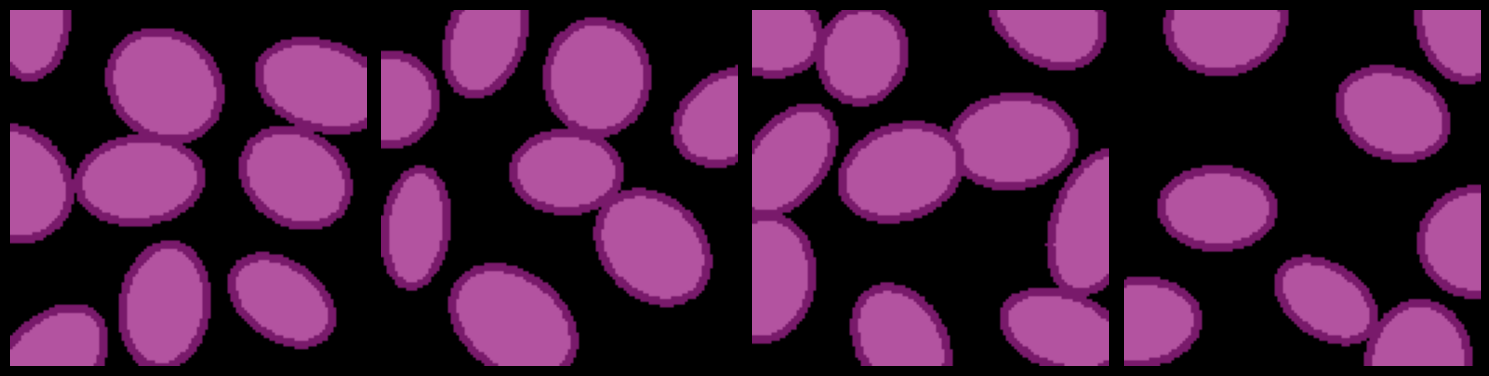

In [3]:
larger_cells_set = larger_cells.build_batch(2000)

show_images(larger_cells_set[:4])

### Eksperyment drugi
Eksperyment ma na celu sprawdzenie błędu SSIM w sytuacji gdy zmienia się kolor komórek.

Konfiguracja komórki

In [4]:
different_colors_conf = GenerationConfig()
different_colors_conf.nucleus.base_color = (134, 80, 34)
different_colors_conf.nucleus.border_color = (29, 40, 182)

different_colors_cells = ImageGenerator(different_colors_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 13 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 17 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 16 centers
Generated 13 

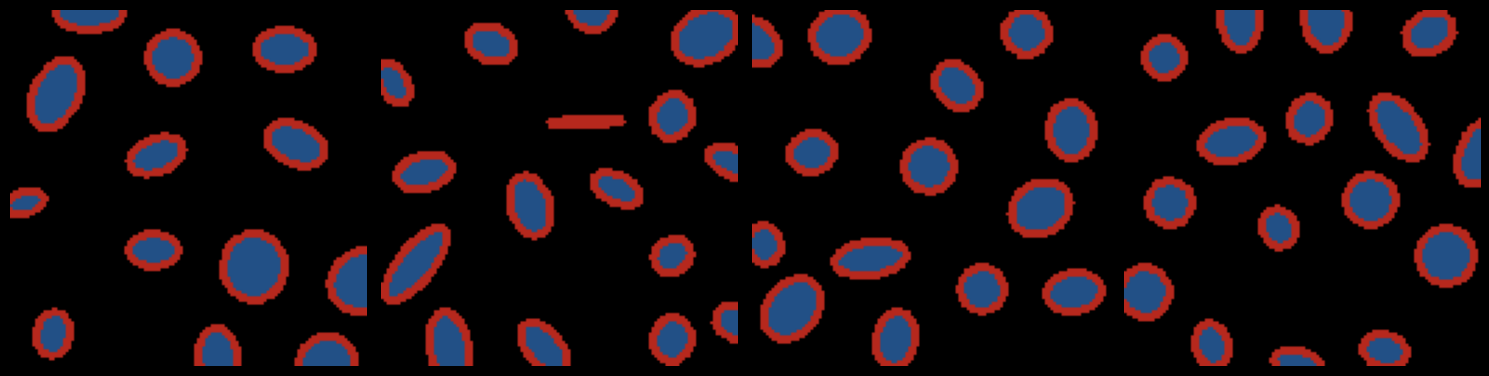

In [5]:
different_color_cells_set = different_colors_cells.build_batch(2000)

show_images(different_color_cells_set[:4])

### Eksperyment trzeci
W eksperymencie sprawdzone zostanie wpływ rozkładu komórek na błąd SSIM.

Konfiguracja komórki

In [6]:
distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = "gaussian"

gaussian_dist_cells = ImageGenerator(distribution_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 

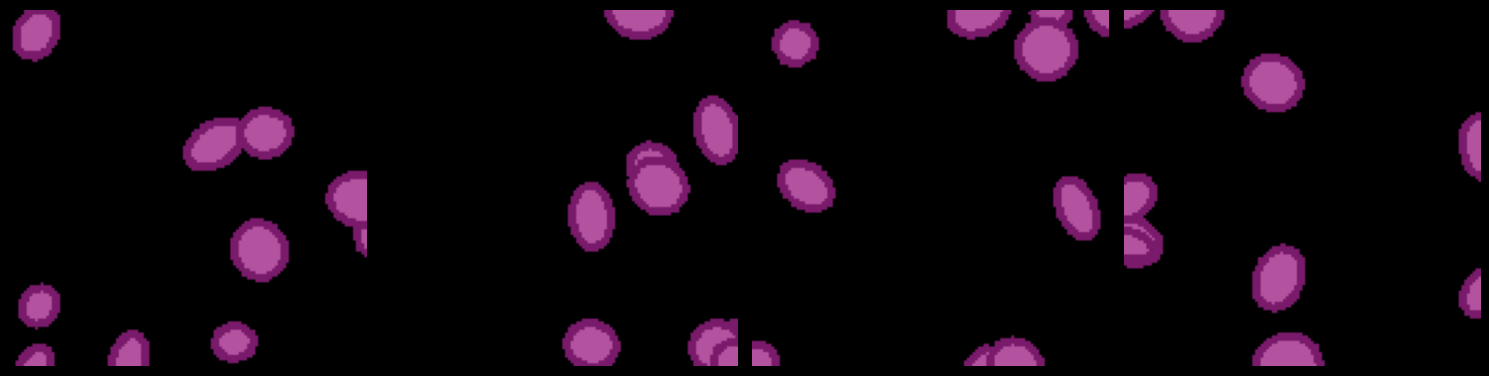

In [7]:
gaussian_dist_set = gaussian_dist_cells.build_batch(2000)

show_images(gaussian_dist_set[:4])

### Eksperyment czwarty
Sprawdzenie wpływu zniekształcenia kształtu komórek za pomocą szumu perlina na wynik SSIM.

In [8]:
perlin_noise_conf = (ImageGenerator()
                     .with_perlin_noise(True))

Utworzenie zbioru i sprawdzenie wyników.

Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 13 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 13 centers
Generated 18 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 13 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 13 

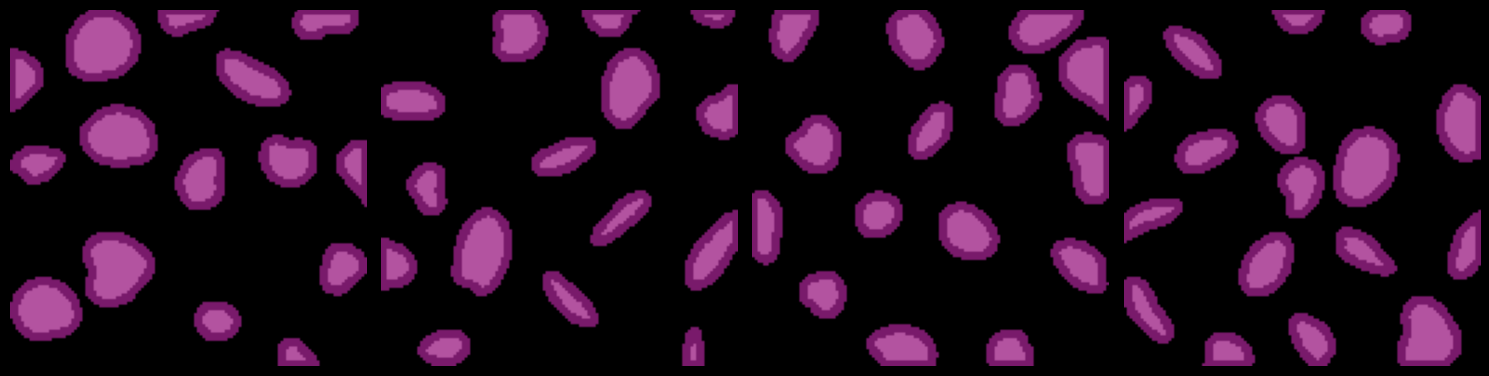

In [9]:
perlin_noise_set = perlin_noise_conf.build_batch(2000)

show_images(perlin_noise_set[:4])

### Eksperyment piąty

Połączenie wszystkich dotychczasowych eksperymentów.


In [10]:
various_conf = (ImageGenerator()
                .with_axes_config(16,18)
                .with_perlin_noise(True)
                .with_clustered_distribution(deviation=1)
                .with_cancer_cells(color=(23,190,40),
                                   border_color=(80,23,22)))

Utworzenie zbioru i sprawdzenie wyników.

Generated 7 centers
Generated 5 centers
Generated 5 centers
Generated 4 centers
Generated 5 centers
Generated 8 centers
Generated 3 centers
Generated 5 centers
Generated 6 centers
Generated 5 centers
Generated 5 centers
Generated 3 centers
Generated 6 centers
Generated 3 centers
Generated 8 centers
Generated 5 centers
Generated 8 centers
Generated 4 centers
Generated 8 centers
Generated 6 centers
Generated 8 centers
Generated 5 centers
Generated 7 centers
Generated 5 centers
Generated 4 centers
Generated 8 centers
Generated 7 centers
Generated 5 centers
Generated 4 centers
Generated 5 centers
Generated 7 centers
Generated 5 centers
Generated 4 centers
Generated 6 centers
Generated 7 centers
Generated 6 centers
Generated 6 centers
Generated 8 centers
Generated 5 centers
Generated 7 centers
Generated 8 centers
Generated 5 centers
Generated 6 centers
Generated 8 centers
Generated 3 centers
Generated 6 centers
Generated 7 centers
Generated 4 centers
Generated 3 centers
Generated 6 centers


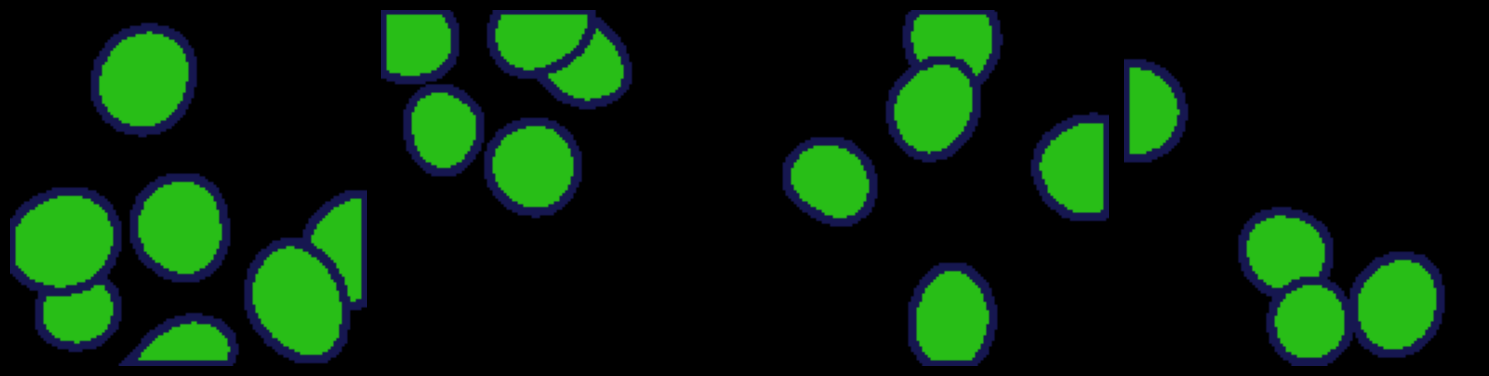

In [11]:
various_conf_set = various_conf.build_batch(2000)
show_images(various_conf_set[:4])

## Enkoder

Przygorowanie zbioru treningowego, walidacyjnego oraz testowego

Generated 16 centers
Generated 18 centers
Generated 13 centers
Generated 13 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 16 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 14 centers
Generated 14 

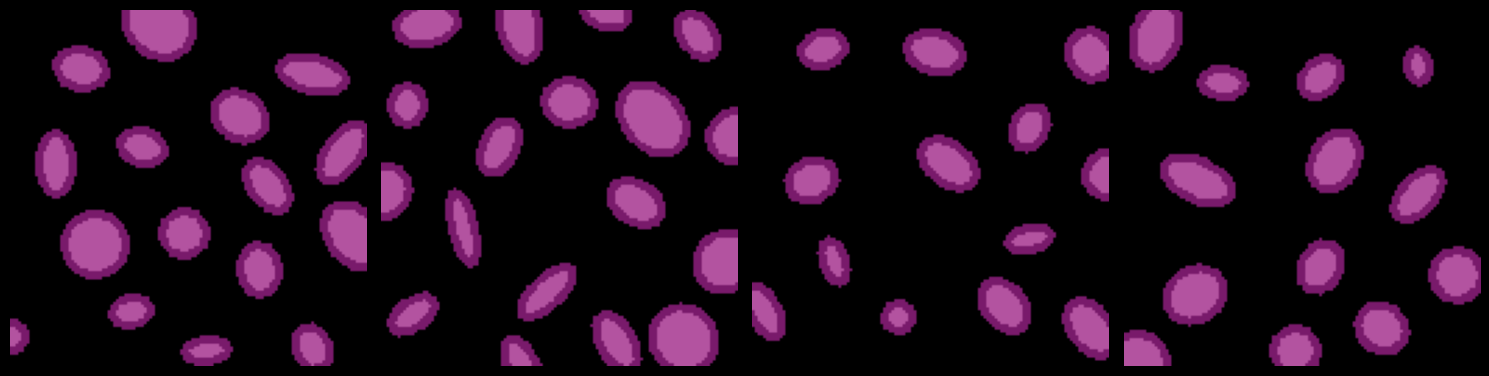

In [12]:
training_set = generate_batch(5000)

show_images(training_set[:4])

Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 13 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 14 centers
Generated 12 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 12 centers
Generated 14 centers
Generated 17 centers
Generated 17 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 15 

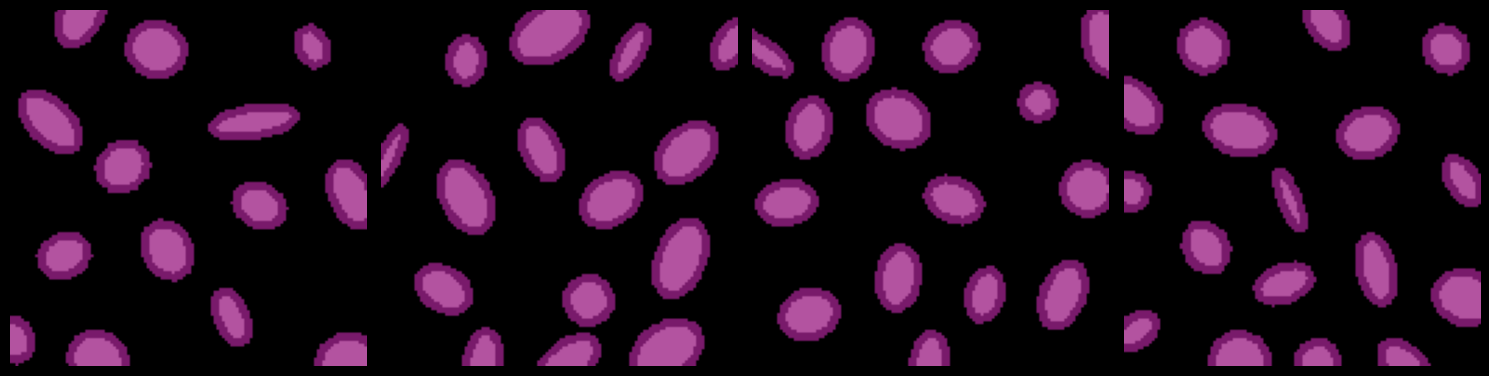

In [13]:
validation_set = generate_batch(1000)

show_images(validation_set[:4])

Generated 17 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 16 centers
Generated 16 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 15 

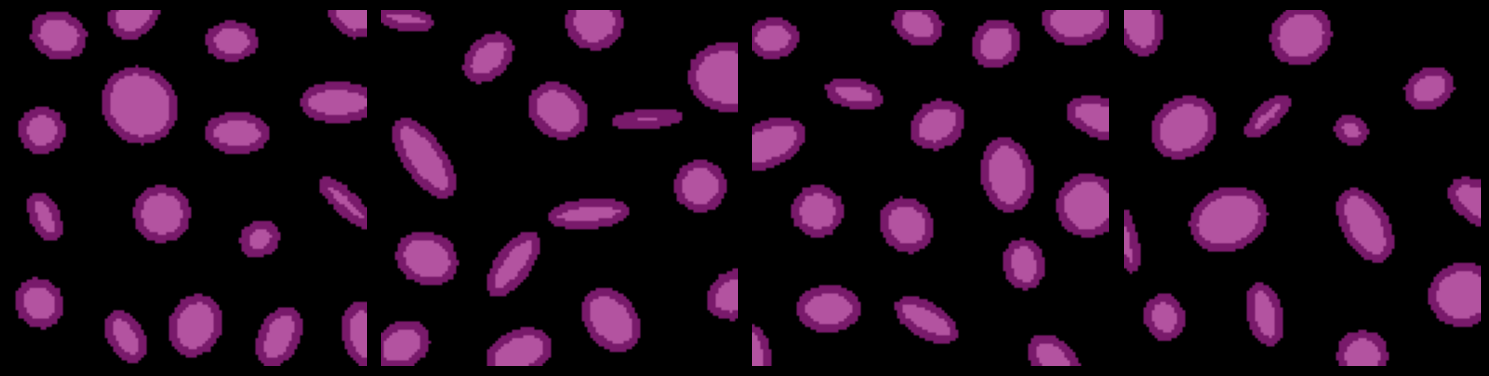

In [14]:
test_set = generate_batch(2000)

show_images(test_set[:4])

Przygotowanie danych dla enkodera

In [15]:
def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

In [16]:
x_test_data = preprocess(test_set)
x_val_data = preprocess(validation_set)
x_traning_data = preprocess(training_set)

In [17]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

Inplementacja enkodera

In [18]:
enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss=ssim_loss, metrics=['mae', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=0.0001,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

history = enkoder.fit(
    x_traning_data, x_traning_data,
    epochs=100,
    shuffle=True,
    callbacks=[reduce_lr, early_stopping],
    validation_data=(x_val_data, x_val_data),
    verbose=1
)
print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 235ms/step - loss: 0.2610 - mae: 0.0957 - mse: 0.0407 - val_loss: 0.0845 - val_mae: 0.0286 - val_mse: 0.0043 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - loss: 0.0605 - mae: 0.0207 - mse: 0.0027 - val_loss: 0.0430 - val_mae: 0.0150 - val_mse: 0.0018 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step - loss: 0.0397 - mae: 0.0144 - mse: 0.0017 - val_loss: 0.0355 - val_mae: 0.0129 - val_mse: 0.0015 - learning_rate: 0.0010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 229ms/step - loss: 0.0334 - mae: 0.0126 - mse: 0.0014 - val_loss: 0.0311 - val_mae: 0.0119 - val_mse: 0.0013 - learning_rate: 0.0010
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - loss: 0.0316 - mae: 0.0119 - mse: 0.0013 - val_loss: 0.0294 - val_mae: 0.0113 - val_mse: 0.0012 - learning_rate: 0.0010
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - loss: 0.0287 - mae: 0.0112 - mse: 0.0012 - val_loss:

In [100]:
history.history

{'loss': [0.260988712310791,
  0.060529693961143494,
  0.039676081389188766,
  0.0334487222135067,
  0.03160688281059265,
  0.02873874455690384,
  0.027661001309752464,
  0.026890944689512253,
  0.026161670684814453,
  0.02502862550318241,
  0.024416986852884293,
  0.02382359839975834,
  0.02306036837399006,
  0.022383341565728188,
  0.02192971110343933,
  0.021410781890153885,
  0.020757371559739113,
  0.02016523666679859,
  0.019605940207839012,
  0.019520072266459465,
  0.018682025372982025,
  0.01835368573665619,
  0.017774367704987526,
  0.017517732456326485,
  0.016892507672309875,
  0.016550404950976372,
  0.01614595763385296,
  0.015827294439077377,
  0.01572687365114689,
  0.01520272996276617,
  0.01490541361272335,
  0.013343038968741894,
  0.013163113035261631,
  0.013076985254883766,
  0.01298445276916027,
  0.012901301495730877,
  0.012807019054889679,
  0.012720847502350807,
  0.012624925933778286,
  0.01252432819455862,
  0.012412787415087223,
  0.012310466729104519,
  0

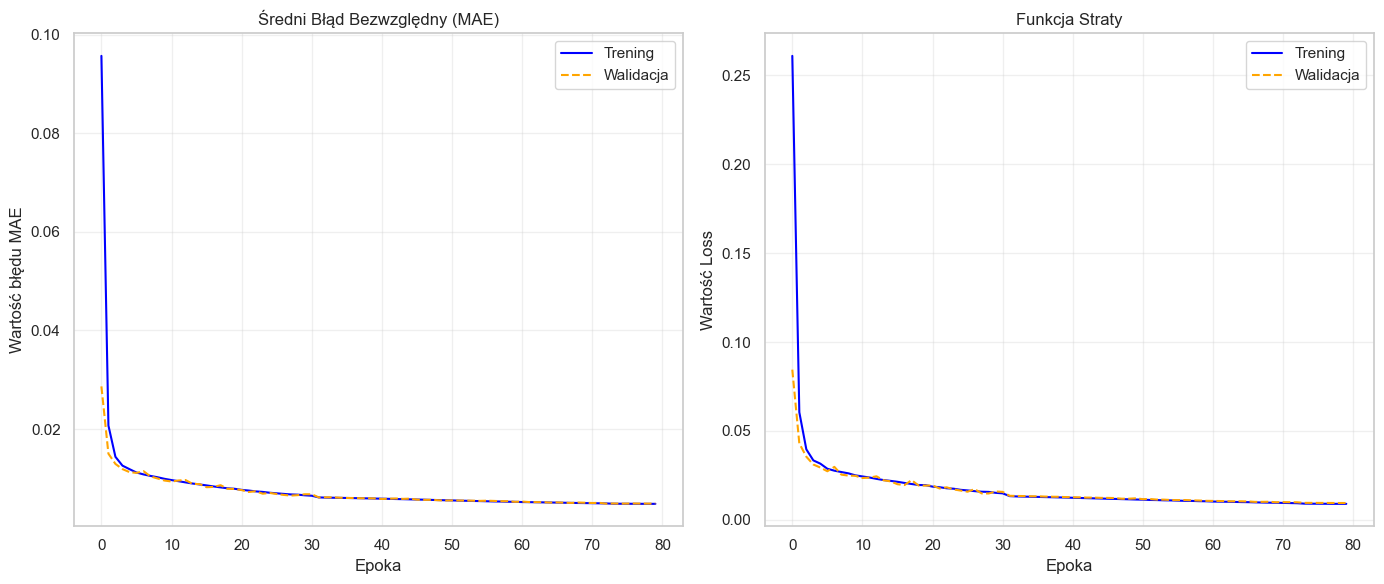

In [101]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Trening', color='blue')
plt.plot(history.history['val_mae'], label='Walidacja', color='orange', linestyle='--')
plt.title('Średni Błąd Bezwzględny (MAE)')
plt.xlabel('Epoka')
plt.ylabel('Wartość błędu MAE')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening', color='blue')
plt.plot(history.history['val_loss'], label='Walidacja', color='orange', linestyle='--')
plt.title('Funkcja Straty')
plt.xlabel('Epoka')
plt.ylabel('Wartość Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()


# plt.savefig('historia_treningu_autoenkodera.png', dpi=300)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
SSIM Normal: 0.009532


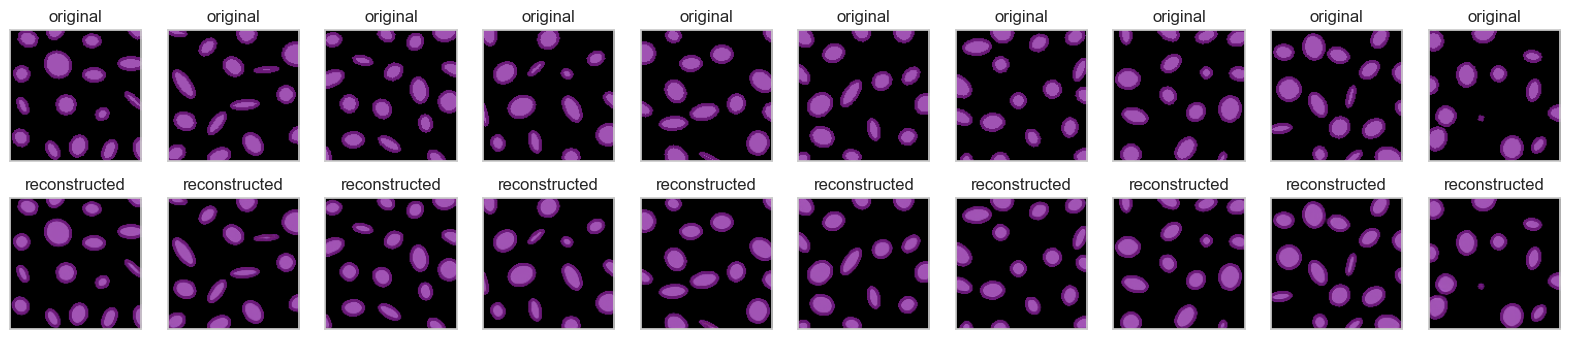

In [102]:
decoded_test = enkoder.predict(x_test_data)
ssim_test = enkoder.evaluate(x_test_data, x_test_data, verbose=0)[0]

print(f"SSIM Normal: {ssim_test:.6f}")

visualize_output(x_test_data, decoded_test, 10)

Wykres błędu SSIM

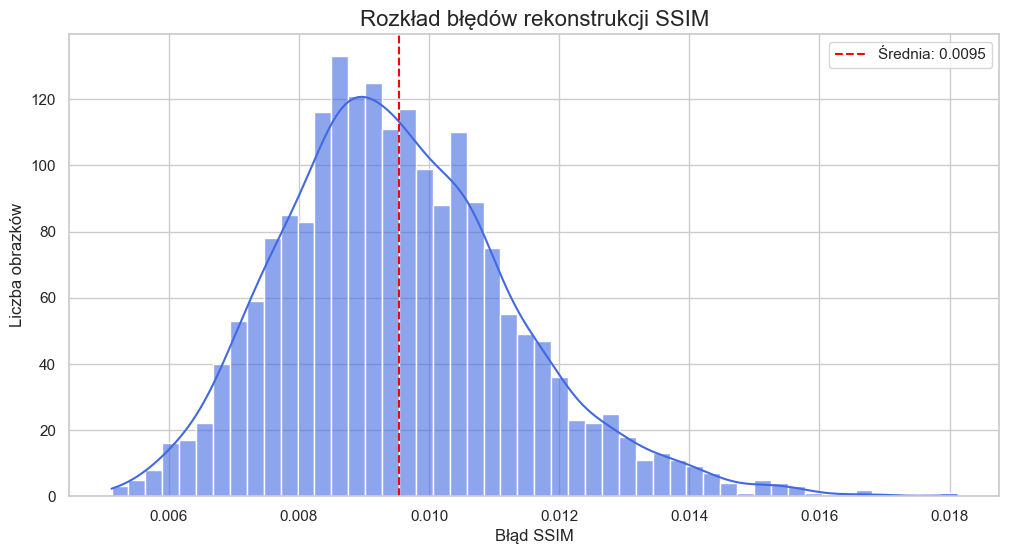

In [103]:
ssim_test_per_image = 1 - tf.image.ssim(x_test_data, decoded_test, max_val=1.0).numpy()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(ssim_test_per_image, bins=50, kde=True, color="royalblue", alpha=0.6)

mean_val = np.mean(ssim_test_per_image)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Średnia: {mean_val:.4f}')

plt.title("Rozkład błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [104]:
test = [{'Eksperyment': 'SSIM test', 'Wynik': ssim_test}]

ssim_dataset = pd.DataFrame(test, columns=['Eksperyment', 'Wynik'])
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009532


### Wyniki eksperymentu pierwszego

Mean Reconstruction Error SSIM: 0.023779


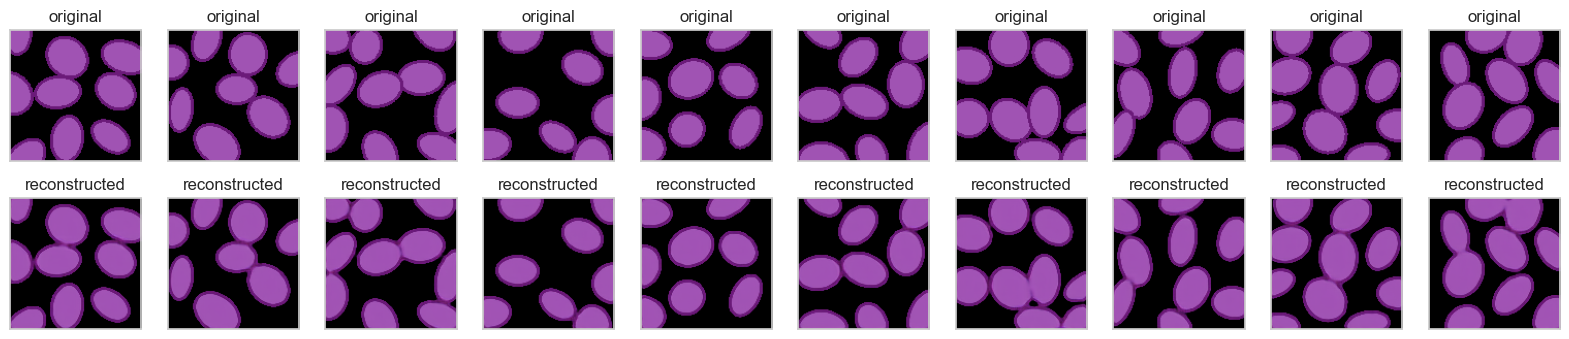

In [105]:
x_large_cells_data = preprocess(larger_cells_set)

decoded_large_cells = enkoder.predict(x_large_cells_data, verbose = 0)
ssim_large = enkoder.evaluate(x_large_cells_data, x_large_cells_data, verbose=0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_large:.6f}")

visualize_output(x_large_cells_data, decoded_large_cells, 10)

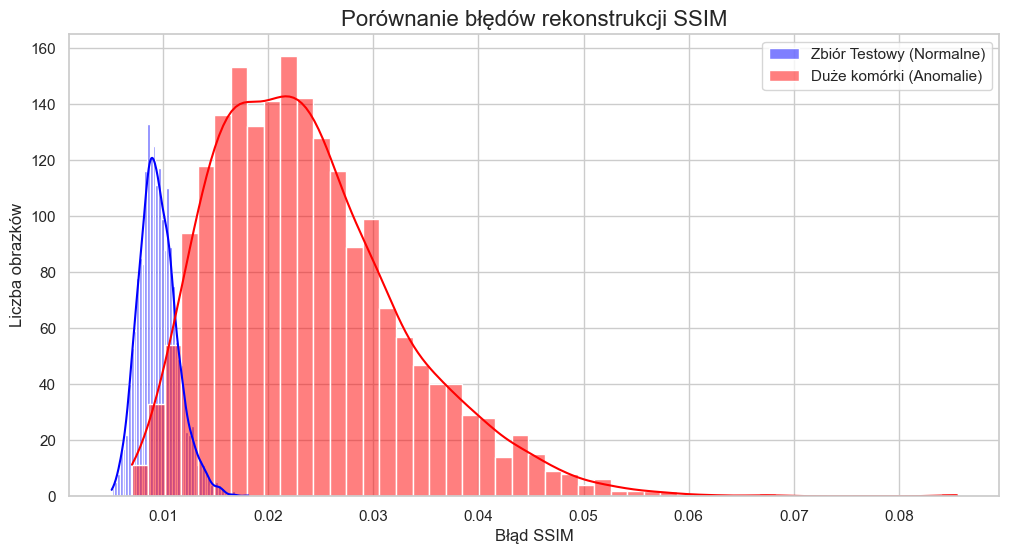

In [106]:
ssim_large_per_image = 1 - tf.image.ssim(x_large_cells_data, decoded_large_cells, max_val=1.0)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_large_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Duże komórki (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

**Hipoteza zerowa**

Zakładamy, że wartość średniego błędu SSIM dla normalnych komórek jest taka sama jak dla anomalii. (Wariant pesymistyczny)

**Hipoteza alternatywna**

Średni błąd SSIM dla anomalii jest większy niż komórek normalnych

**Aby wyeliminować podejrzenie losowości w wynikach SSIM zastosowano test t-studenta dla błędu SSIM.**

Interpretacja:
* Jeżeli p_value jest mniejsze niż 0.05 oznacza to, że szansa na to, że wynik uzyskaliśmy przez losowe zbiegnięcie się danych jest mniejsza niż 0.0001% i jest praktycznie niemożliwa. Odrzucamy hipotezę o szczęściu w losowaniu obrazów i model działa.
* Jeżeli p_value jest większe od 0.05 oznacza to, że istnieje ryzyko, że różnica wynika z przypadku. Pesymistyczna hipoteza zerowa mogła mieć miejsce.

In [107]:
t_stat1, p_val1 = ttest_ind(ssim_large_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat1:.4f}")
print(f"P-value: {p_val1:.30f}")

Statystyka t: 68.8219
P-value: 0.000000000000000000000000000000


In [108]:
larger_cells = [{'Eksperyment': 'SSIM for larger cells', 'Wynik': ssim_large}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(larger_cells)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009532
1,SSIM for larger cells,0.023779


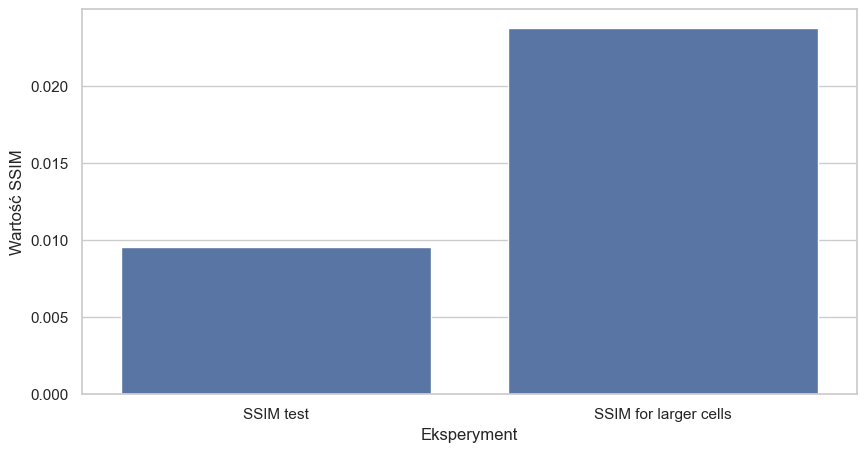

In [109]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

### Wyniki eksperymentu drugiego

Mean Reconstruction Error SSIM: 0.220466


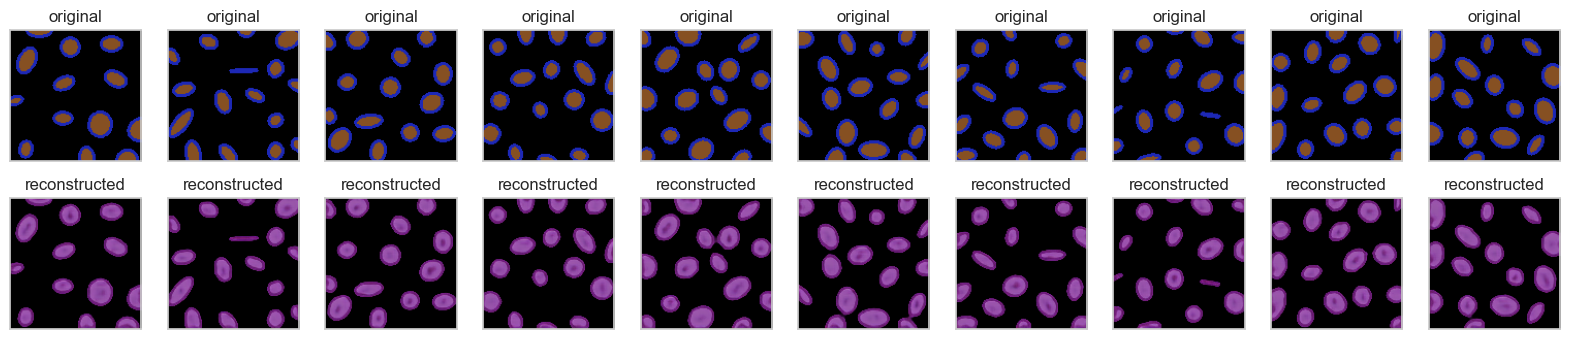

In [110]:
x_diff_color_cells_data = preprocess(different_color_cells_set)

decoded_diff_colors_cells = enkoder.predict(x_diff_color_cells_data,verbose = 0)
ssim_color = enkoder.evaluate(x_diff_color_cells_data, x_diff_color_cells_data, verbose=0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_color:.6f}")

visualize_output(x_diff_color_cells_data, decoded_diff_colors_cells, 10)

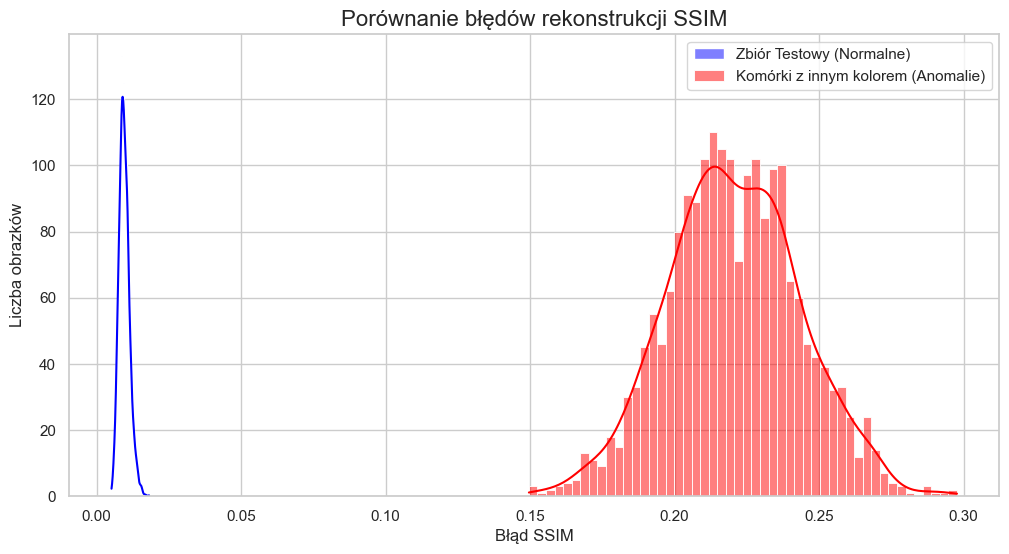

In [111]:
ssim_diff_color_per_image = 1 - tf.image.ssim(x_diff_color_cells_data, decoded_diff_colors_cells, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [112]:
t_stat2, p_val2 = ttest_ind(ssim_diff_color_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat2:.4f}")
print(f"P-value: {p_val2:.30f}")

Statystyka t: 412.1491
P-value: 0.000000000000000000000000000000


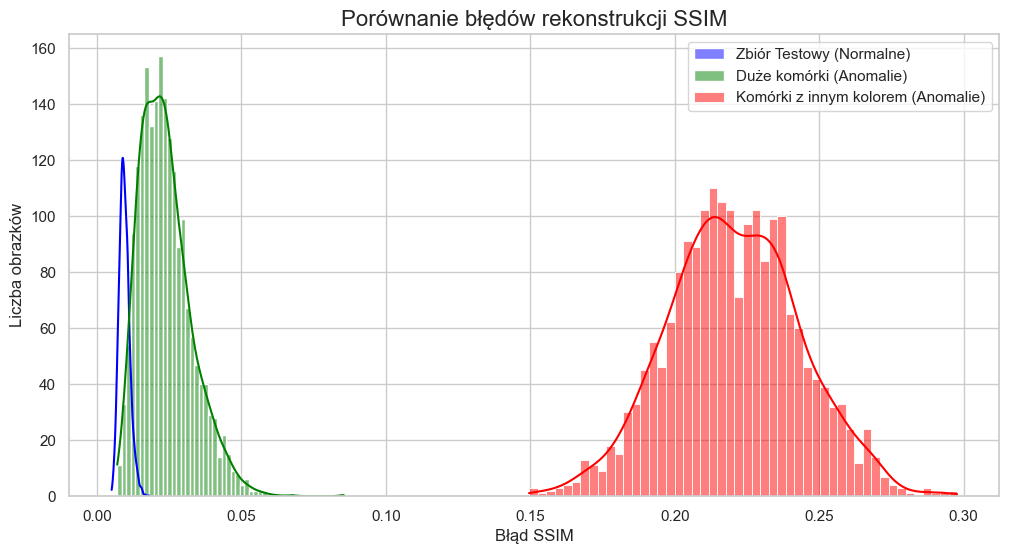

In [113]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
sns.histplot(ssim_large_per_image, bins=50, kde=True,
             color='green', alpha=0.5, label='Duże komórki (Anomalie)')
sns.histplot(ssim_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [114]:
diff_color_cells = [{'Eksperyment': 'SSIM with different color', 'Wynik': ssim_color}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(diff_color_cells)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009532
1,SSIM for larger cells,0.023779
2,SSIM with different color,0.220466


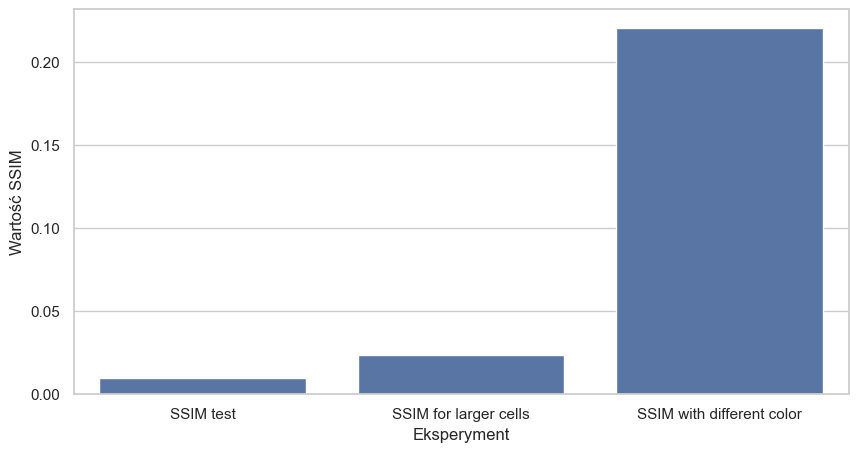

In [115]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

### Wyniki eksperymentu trzeciego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
Mean Reconstruction Error SSIM: 0.013870


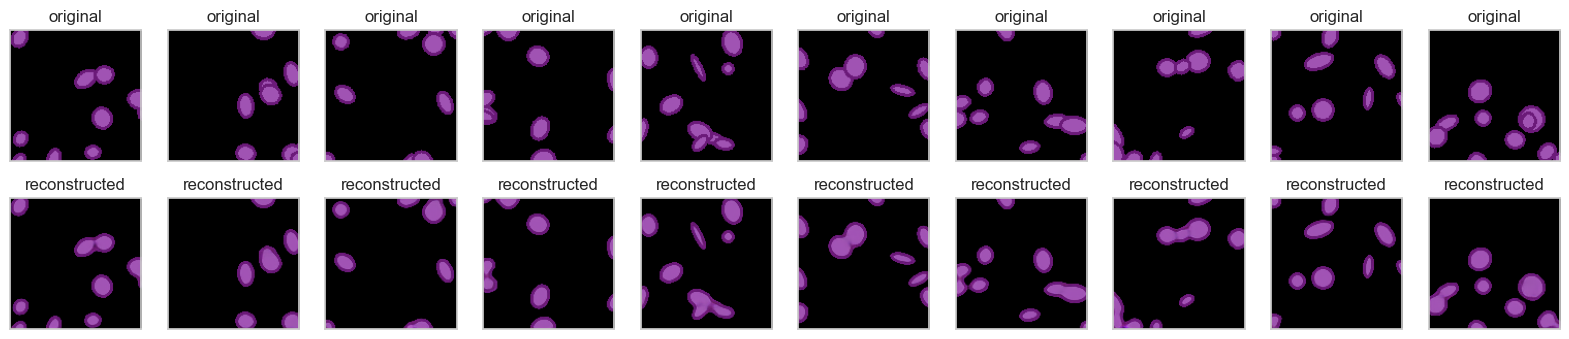

In [116]:
x_gaussian_dist_data = preprocess(gaussian_dist_set)

decoded_gaussian_dist_cells = enkoder.predict(x_gaussian_dist_data)
ssim_gaussian = enkoder.evaluate(x_gaussian_dist_data,x_gaussian_dist_data,verbose = 0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_gaussian:.6f}")

visualize_output(x_gaussian_dist_data, decoded_gaussian_dist_cells, 10)

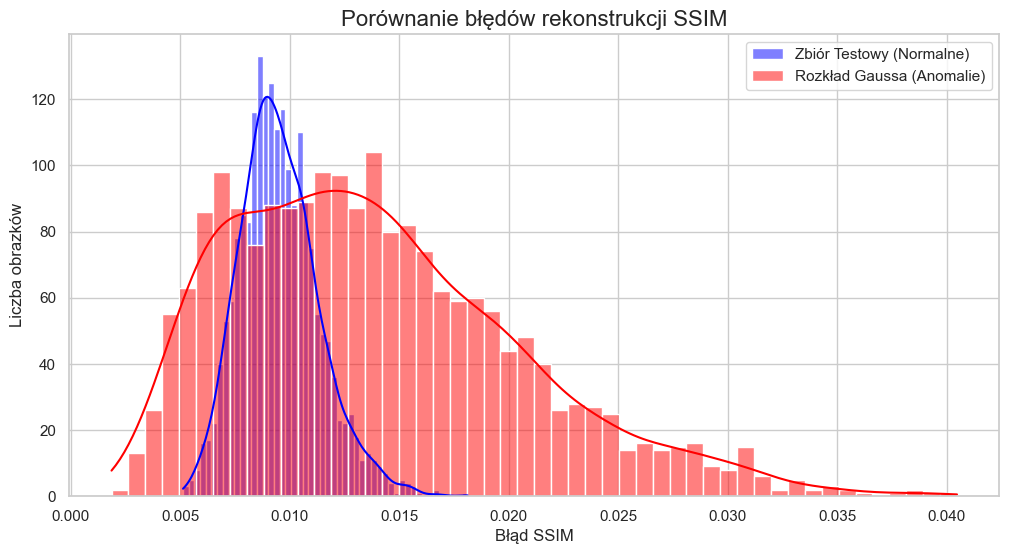

In [117]:
ssim_gaussian_per_image = 1 - tf.image.ssim(x_gaussian_dist_data, decoded_gaussian_dist_cells, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_gaussian_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Rozkład Gaussa (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [118]:
t_stat3, p_val3 = ttest_ind(ssim_gaussian_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat3:.4f}")
print(f"P-value: {p_val3:.30f}")

Statystyka t: 28.2089
P-value: 0.000000000000000000000000000000


In [119]:
gaussian_dist = [{'Eksperyment': "SSIM with Gauss's distribution", 'Wynik': ssim_gaussian}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(gaussian_dist)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009532
1,SSIM for larger cells,0.023779
2,SSIM with different color,0.220466
3,SSIM with Gauss's distribution,0.013870


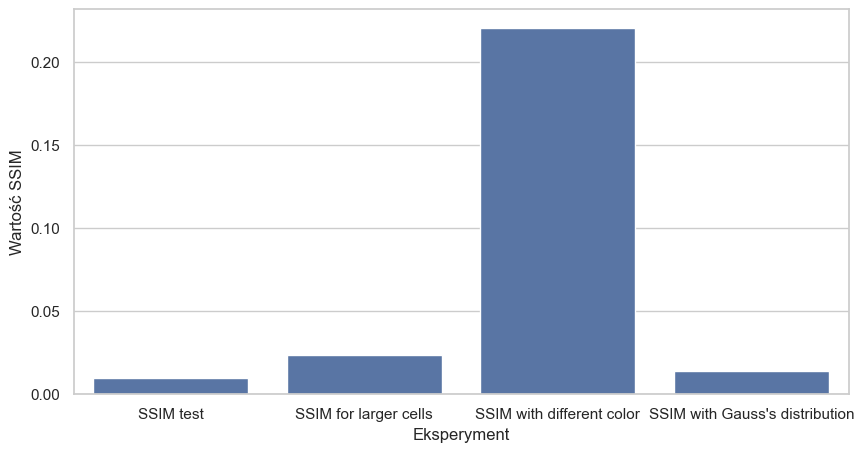

In [120]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

Wyniki eksperymentu czwartego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
Mean Reconstruction Error SSIM: 0.013287


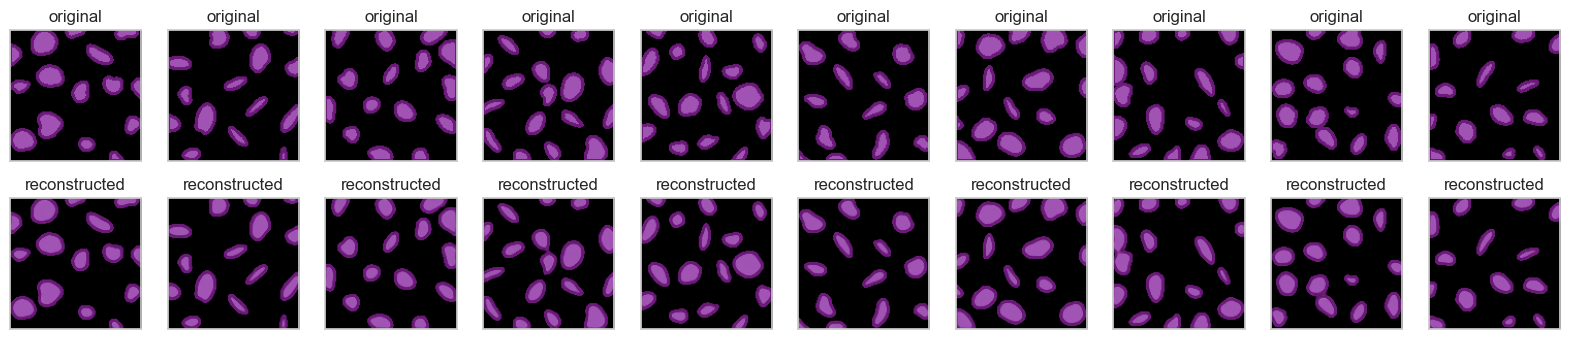

In [121]:
x_perlin_data = preprocess(perlin_noise_set)

decoded_perlin_noise_cells = enkoder.predict(x_perlin_data)
ssim_perlin = enkoder.evaluate(x_perlin_data,x_perlin_data,verbose = 0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_perlin:.6f}")

visualize_output(x_perlin_data, decoded_perlin_noise_cells, 10)

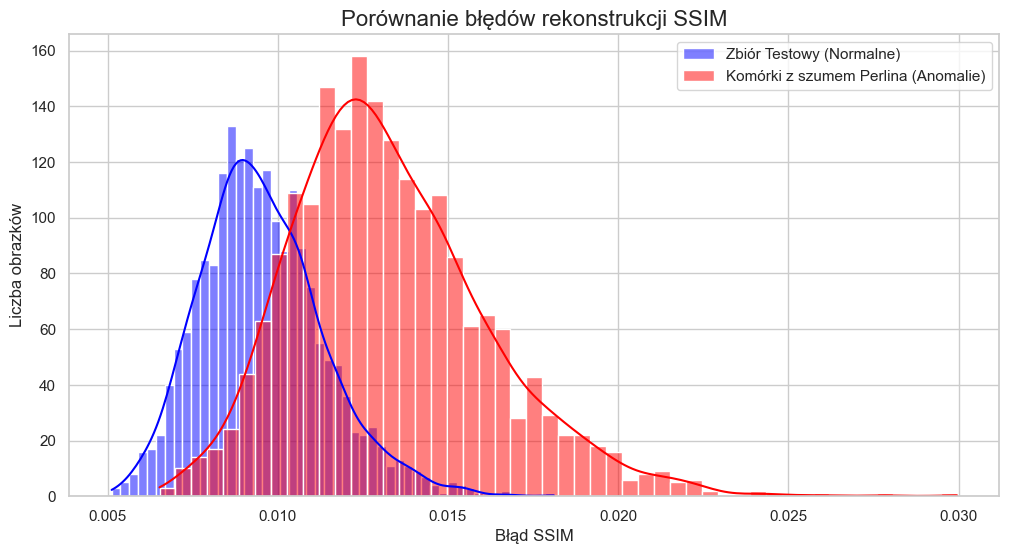

In [122]:
ssim_perlin_per_image = 1 - tf.image.ssim(x_perlin_data, decoded_perlin_noise_cells, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_perlin_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z szumem Perlina (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [123]:
t_stat4, p_val4 = ttest_ind(ssim_perlin_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat4:.4f}")
print(f"P-value: {p_val4:.30f}")

Statystyka t: 49.2544
P-value: 0.000000000000000000000000000000


In [124]:
perlin_cells = [{'Eksperyment': "SSIM with Perlin Noise", 'Wynik': ssim_perlin}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(perlin_cells)], ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009532
1,SSIM for larger cells,0.023779
2,SSIM with different color,0.220466
3,SSIM with Gauss's distribution,0.013870
4,SSIM with Perlin Noise,0.013287


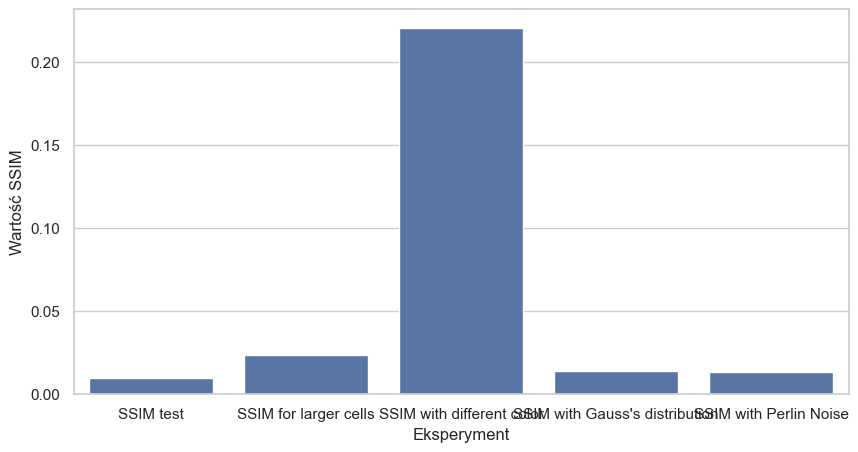

In [125]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

Wyniki eksperymentu piątego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Mean Reconstruction Error SSIM: 0.267601


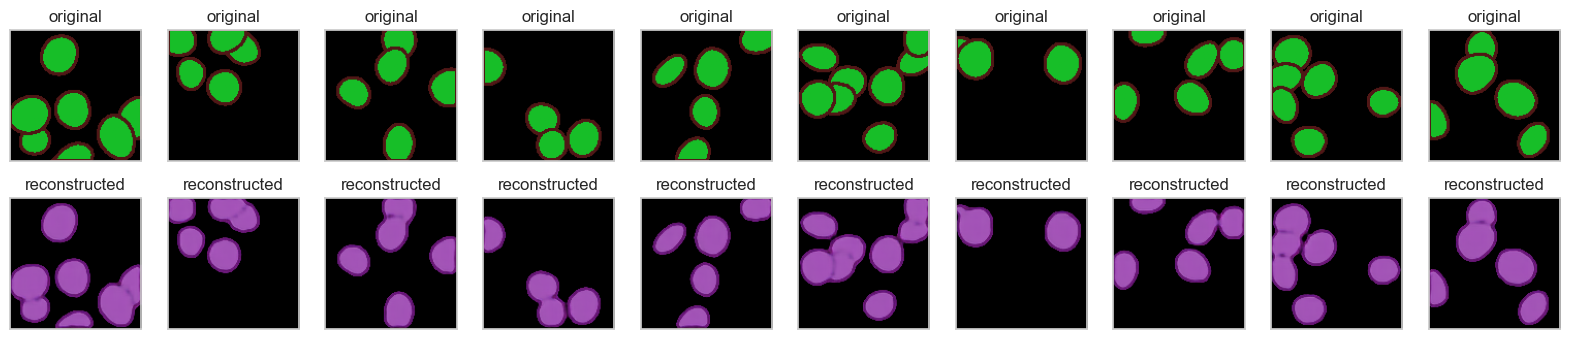

In [126]:
x_various_conf_data = preprocess(various_conf_set)

decoded_various_conf = enkoder.predict(x_various_conf_data)
ssim_various_conf = enkoder.evaluate(x_various_conf_data,x_various_conf_data,verbose = 0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_various_conf:.6f}")

visualize_output(x_various_conf_data, decoded_various_conf, 10)

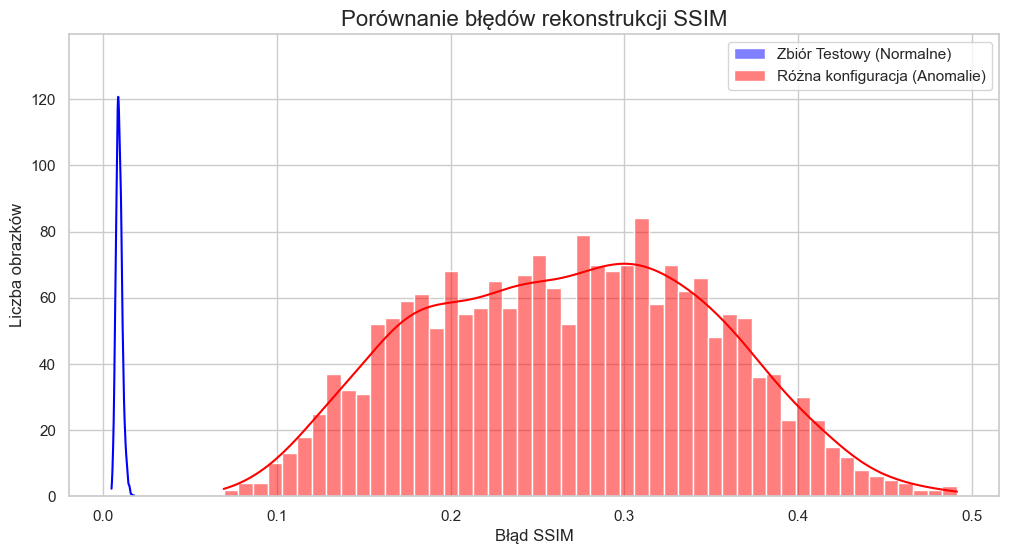

In [127]:
ssim_various_per_image = 1 - tf.image.ssim(x_various_conf_data, decoded_various_conf, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_various_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Różna konfiguracja (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [128]:
t_stat5, p_val5 = ttest_ind(ssim_various_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat5:.4f}")
print(f"P-value: {p_val5:.30f}")

Statystyka t: 140.1349
P-value: 0.000000000000000000000000000000


In [129]:
various_conf = [{'Eksperyment': "SSIM with various configuration", 'Wynik': 1 - ssim_various_conf}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(various_conf)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009532
1,SSIM for larger cells,0.023779
2,SSIM with different color,0.220466
3,SSIM with Gauss's distribution,0.013870
4,SSIM with Perlin Noise,0.013287
5,SSIM with various configuration,0.732399


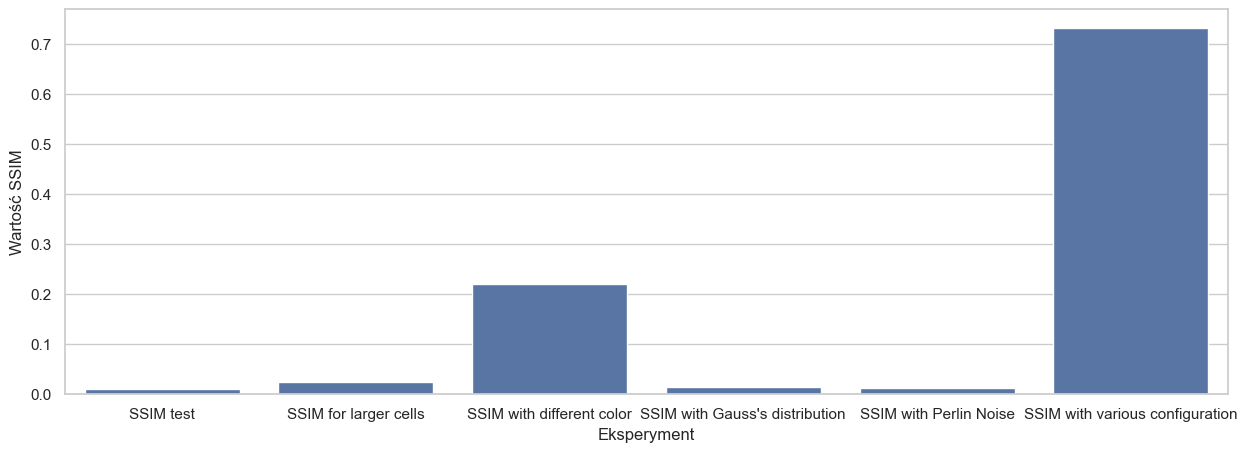

In [130]:
plt.figure(figsize=(15, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()